In [25]:
import glob, os, shutil, sys

hits = glob.glob("/kaggle/input/**/spectral/encoder", recursive=True)
assert hits, "spectral-code not found - run: !ls -R /kaggle/input | head -40"
CODE_ROOT = os.path.dirname(os.path.dirname(hits[0]))
print("code root:", CODE_ROOT)

BACKEND = "/kaggle/working/backend"
os.makedirs(BACKEND, exist_ok=True)
for name in ("spectral", "tools"):
    dst = os.path.join(BACKEND, name)
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(os.path.join(CODE_ROOT, name), dst)

os.chdir(BACKEND)
sys.path.insert(0, BACKEND)

sys.path.insert(0, os.path.join(BACKEND, "spectral", "decoder"))

from spectral.encoder.audio_encoder import encode
from spectral.decoder.stft_decoder import decode
from spectral.decoder.image_reconstructor import recover_activation
from spectral.channel.effects import apply_chain
print("all imports ok")

code root: /kaggle/input/datasets/utshavsaha/spectral-code
all imports ok


In [26]:
%%writefile /kaggle/working/backend/tools/make_dataset.py
"""Generate (degraded, clean) activation pairs for the Track 1 restoration model.

Run from backend/:
    python -m tools.make_dataset --sources <dir> --out <dir> --variants 2
Smoke test:
    python -m tools.make_dataset --sources <dir> --out <dir> --limit 10
"""

import os

# one BLAS thread per worker process, or N workers x N threads fight over N cores
for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_var, "1")

import argparse
import hashlib
import json
from multiprocessing import Pool
from pathlib import Path

import numpy as np
from PIL import Image

from spectral.encoder.audio_encoder import encode
from spectral.decoder.stft_decoder import decode
from spectral.decoder.image_reconstructor import recover_activation
from spectral.channel.effects import apply_chain

ROWS = COLS = 128
MODE = "RGB"
SAMPLE_RATE = 44100
FRAME_DURATION = 0.1
GRAY_LEVELS = 16
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

# Augment the SOURCE image before encoding, never the finished pairs: rows are
# frequencies and damage is row-dependent, so flipping a degraded pair would
# put low-pass damage at the bottom, which never happens physically.
TRANSFORMS = [None,
              Image.Transpose.FLIP_LEFT_RIGHT,
              Image.Transpose.FLIP_TOP_BOTTOM,
              Image.Transpose.ROTATE_180]


def sample_chain(rng):
    """~15% clean; clipping weighted up since it has no analytic inverse."""
    if rng.random() < 0.15:
        return []

    chain = []
    kind = rng.choice(["clip", "lowpass", "bandstop", "echo", "resample"],
                      p=[0.35, 0.18, 0.17, 0.15, 0.15])

    if kind == "lowpass":
        chain.append({"type": "lowpass", "cutoff": float(rng.uniform(2500, 7000))})
    elif kind == "bandstop":
        lo = float(rng.uniform(1500, 6000))
        chain.append({"type": "bandstop", "low": lo, "high": lo + float(rng.uniform(300, 1200))})
    elif kind == "echo":
        chain.append({"type": "echo", "delay": float(rng.uniform(0.02, 0.15)),
                      "decay": float(rng.uniform(0.2, 0.6))})
    elif kind == "clip":
        chain.append({"type": "clip", "threshold": float(rng.uniform(0.15, 0.5))})
    elif kind == "resample":
        chain.append({"type": "resample",
                      "target_rate": int(rng.choice([8000, 11025, 16000, 22050])),
                      "anti_alias": bool(rng.random() < 0.5)})

    if rng.random() < 0.7:
        chain.append({"type": "noise", "snr_db": float(rng.uniform(10, 40))})
    return chain


def encode_once(image):
    """Returns the activation the encoder ACTUALLY sent - that is the ground truth."""
    audio, metadata, activation = encode(
        image, target_width=COLS, target_height=ROWS,
        sample_rate=SAMPLE_RATE, frame_duration=FRAME_DURATION,
        gray_levels=GRAY_LEVELS, mode=MODE, security_enabled=False,
    )
    return audio, metadata, np.asarray(activation, dtype=np.float32)


def degraded_activation(audio, metadata, chain):
    out = apply_chain(audio, metadata["sample_rate"], chain)

    # alignment is known, so slice instead of synchronize()
    per_channel = metadata["columns"] * metadata["frame_samples"]
    needed = 3 * per_channel
    if len(out) < needed:
        out = np.concatenate([out, np.zeros(needed - len(out))])
    out = out[:needed]

    # TODO(Phase 1): calibration inversion + echo deconvolution go here,
    # between decode() and recover_activation().
    channels = [
        recover_activation(decode(out[i * per_channel:(i + 1) * per_channel], metadata), metadata)
        for i in range(3)
    ]
    return np.stack(channels, axis=-1).astype(np.float32)


def seed_for(path):
    return int(hashlib.sha256(path.name.encode()).hexdigest()[:16], 16)


_VARIANTS = 2


def _init_worker(variants):
    global _VARIANTS
    _VARIANTS = variants


def process_one(path_str):
    """Never raises - one bad image must not kill the run."""
    path = Path(path_str)
    try:
        rng = np.random.default_rng(seed_for(path))
        source = Image.open(path).convert("RGB")
        results = []

        for t_index, transform in enumerate(TRANSFORMS):
            image = source if transform is None else source.transpose(transform)
            audio, metadata, clean = encode_once(image)
            clean16 = clean.astype(np.float16)

            for v in range(_VARIANTS):
                chain = sample_chain(rng)
                x = degraded_activation(audio, metadata, chain).astype(np.float16)
                if x.shape != clean16.shape:
                    raise ValueError(f"shape mismatch: {x.shape} vs {clean16.shape}")
                results.append((x, clean16, {"source": path.name, "transform": t_index,
                                             "variant": v, "chain": chain}))
        return results, None

    except Exception as exc:
        return [], f"{path.name}: {type(exc).__name__}: {exc}"


def write_shard(out_dir, index, x_buf, y_buf, meta_buf):
    np.savez_compressed(out_dir / f"shard_{index:04d}.npz", x=np.stack(x_buf), y=np.stack(y_buf))
    (out_dir / f"shard_{index:04d}.json").write_text(json.dumps(meta_buf))


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--sources", required=True)
    ap.add_argument("--out", required=True)
    ap.add_argument("--variants", type=int, default=2)
    ap.add_argument("--shard-size", type=int, default=256)
    ap.add_argument("--workers", type=int, default=os.cpu_count() or 1)
    ap.add_argument("--limit", type=int, default=None)
    args = ap.parse_args()

    out_dir = Path(args.out)
    out_dir.mkdir(parents=True, exist_ok=True)

    paths = sorted(str(p) for p in Path(args.sources).rglob("*") if p.suffix.lower() in IMAGE_EXTS)
    if args.limit:
        paths = paths[:args.limit]
    if not paths:
        raise SystemExit(f"No images found under {args.sources}")

    total = len(paths) * len(TRANSFORMS) * args.variants
    print(f"{len(paths)} images x {len(TRANSFORMS)} transforms x {args.variants} variants "
          f"= ~{total} pairs, {args.workers} workers", flush=True)

    x_buf, y_buf, meta_buf = [], [], []
    shard = done = pairs = 0
    errors = []

    with Pool(args.workers, initializer=_init_worker, initargs=(args.variants,)) as pool:
        for results, err in pool.imap(process_one, paths, chunksize=2):
            done += 1
            if err:
                errors.append(err)
                print(f"  skip {err}", flush=True)
            for x, y, meta in results:
                x_buf.append(x); y_buf.append(y); meta_buf.append(meta)

            if len(x_buf) >= args.shard_size:
                write_shard(out_dir, shard, x_buf, y_buf, meta_buf)
                pairs += len(x_buf)
                print(f"  shard {shard:04d}  {len(x_buf)} pairs  (image {done}/{len(paths)})", flush=True)
                x_buf, y_buf, meta_buf = [], [], []
                shard += 1

    if x_buf:
        write_shard(out_dir, shard, x_buf, y_buf, meta_buf)
        pairs += len(x_buf)
        shard += 1

    (out_dir / "errors.txt").write_text("\n".join(errors))
    print(f"done: {pairs} pairs in {shard} shards, {len(errors)} skipped", flush=True)


if __name__ == "__main__":
    main()

Overwriting /kaggle/working/backend/tools/make_dataset.py


In [27]:
from PIL import Image
from collections import Counter

pngs = glob.glob("/kaggle/input/**/*.png", recursive=True)
folders = Counter(os.path.dirname(p) for p in pngs)
assert folders, "no PNGs found - the DIV2K input may still be a zip; run !ls -R /kaggle/input | head -40"

print(f"{'count':>6}  {'width':>6}  folder")
for folder, count in sorted(folders.items(), key=lambda kv: -kv[1]):
    first = sorted(glob.glob(f"{folder}/*.png"))[0]
    print(f"{count:>6}  {Image.open(first).width:>6}  {folder}")

 count   width  folder
   800    2040  /kaggle/input/datasets/cyan803/div2k-zip/DIV2K/HR
   800     680  /kaggle/input/datasets/cyan803/div2k-zip/DIV2K/LR_bicubic/X3
   800     510  /kaggle/input/datasets/cyan803/div2k-zip/DIV2K/LR_bicubic/X4
   800    1020  /kaggle/input/datasets/cyan803/div2k-zip/DIV2K/LR_bicubic/X2


In [28]:
DIV2K_TRAIN = "/kaggle/input/datasets/cyan803/div2k-zip/DIV2K/HR"
DIV2K_VALID = None
print(len(glob.glob(f"{DIV2K_TRAIN}/*.png")), "train")
if DIV2K_VALID:
    print(len(glob.glob(f"{DIV2K_VALID}/*.png")), "valid")

800 train


In [29]:
import random
from pathlib import Path

smoke = Path("/kaggle/working/smoke")
shutil.rmtree(smoke, ignore_errors=True)
smoke.mkdir()
random.seed(0)
for f in random.sample(sorted(glob.glob(f"{DIV2K_TRAIN}/*.png")), 5):
    shutil.copy(f, smoke)
print(len(list(smoke.iterdir())), "smoke images")

5 smoke images


In [33]:
!sed -i 's/from .synchronizer import/from synchronizer import/g' /kaggle/working/backend/spectral/decoder/stft_decoder.py

In [34]:
!cd /kaggle/working/backend && PYTHONPATH="/kaggle/working/backend:/kaggle/working/backend/spectral/decoder" python -m tools.make_dataset --sources /kaggle/working/smoke --out /kaggle/working/pairs_smoke --variants 2

5 images x 4 transforms x 2 variants = ~40 pairs, 4 workers
done: 40 pairs in 1 shards, 0 skipped


x (40, 128, 128, 3) y (40, 128, 128, 3)


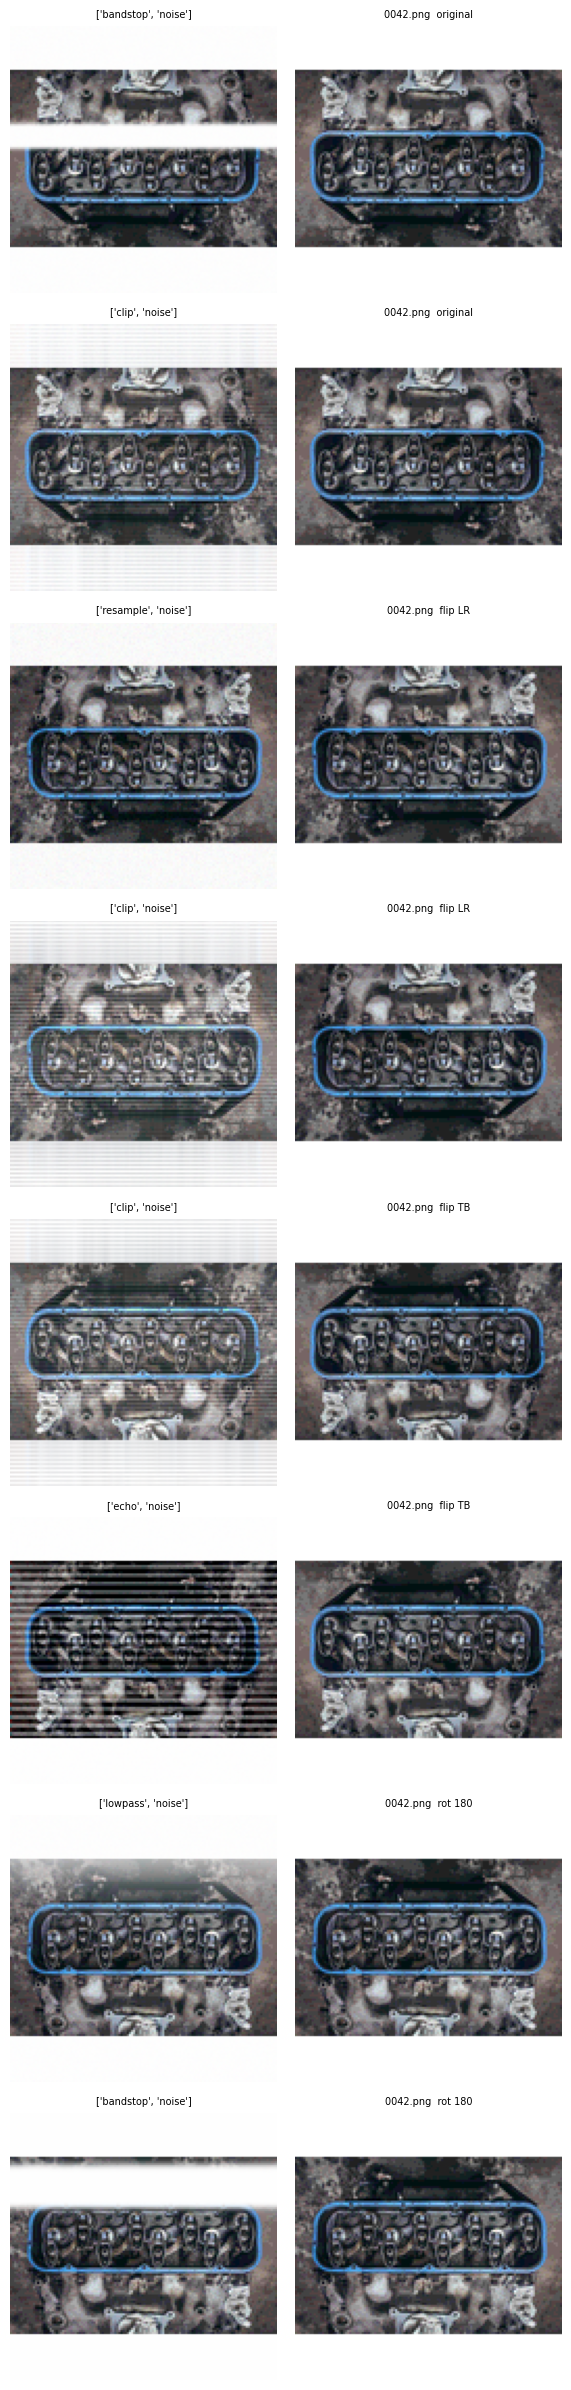

In [35]:
import json, numpy as np, matplotlib.pyplot as plt

d = np.load("/kaggle/working/pairs_smoke/shard_0000.npz")
meta = json.load(open("/kaggle/working/pairs_smoke/shard_0000.json"))
x, y = d["x"].astype(np.float32), d["y"].astype(np.float32)
print("x", x.shape, "y", y.shape)

names = ["original", "flip LR", "flip TB", "rot 180"]
fig, axes = plt.subplots(8, 2, figsize=(6, 24))
for i, ax in enumerate(axes):
    ax[0].imshow(1 - np.clip(x[i], 0, 1))
    ax[0].set_title(str([c["type"] for c in meta[i]["chain"]]), fontsize=7)
    ax[1].imshow(1 - np.clip(y[i], 0, 1))
    ax[1].set_title(f'{meta[i]["source"]}  {names[meta[i]["transform"]]}', fontsize=7)
    ax[0].axis("off"); ax[1].axis("off")
plt.tight_layout()

In [36]:
# ===== Cell 8 — Track 2 (Gen B upscaler) dataset =====
import glob, json, numpy as np
from pathlib import Path
from PIL import Image

SMALL  = 32        # what Gen B transmits — match your real sender
BIG    = 128       # upscaler output size
LEVELS = 4         # levels per RGB channel in Gen B
SYMBOL_ERROR_RATE = 3e-4   # measured from your real call (1 bad value in ~3072)
HOLDOUT = 40       # used only if there is no DIV2K_VALID folder

OUT2 = Path("/kaggle/working/pairs_upscale")
OUT2.mkdir(parents=True, exist_ok=True)


def center_crop(img):
    """Crop to a square so the subject fills the frame — no letterbox padding,
    so no call time is spent transmitting white. Must match the sender."""
    w, h = img.size
    s = min(w, h)
    left, top = (w - s) // 2, (h - s) // 2
    return img.crop((left, top, left + s, top + s))


def quantize(a, levels):
    return np.round(a * (levels - 1)) / (levels - 1)


def base_pair(path):
    """Clean 128x128 target and the exact 32x32 4-level image Gen B sends.
    Resizes run once per source image; flips are applied to the arrays after,
    which is equivalent because flipping commutes with resizing."""
    img = center_crop(Image.open(path).convert("RGB"))
    y = np.asarray(img.resize((BIG, BIG), Image.LANCZOS), dtype=np.float32) / 255.0
    x = np.asarray(img.resize((SMALL, SMALL), Image.LANCZOS), dtype=np.float32) / 255.0
    return quantize(x, LEVELS), y


# Flips are safe on Track 2 even after the fact: no frequency axis here,
# so nothing physical depends on which way up the image is.
FLIPS = {
    "original": lambda a: a,
    "flip_lr":  lambda a: a[:, ::-1],
    "flip_tb":  lambda a: a[::-1, :],
    "rot_180":  lambda a: a[::-1, ::-1],
}


def inject_errors(x, rng):
    """Residual symbol errors that survive Hamming(7,4): an isolated channel
    value replaced by a random level. Applied AFTER flipping so each variant
    gets its own independent errors."""
    x = x.copy()
    if SYMBOL_ERROR_RATE > 0:
        hit = rng.random(x.shape) < SYMBOL_ERROR_RATE
        x[hit] = rng.integers(0, LEVELS, hit.sum()) / (LEVELS - 1)
    return x


def build(paths, name, seed):
    rng = np.random.default_rng(seed)
    xs, ys, meta = [], [], []
    for i, p in enumerate(paths):
        try:
            x0, y0 = base_pair(p)
        except Exception as exc:
            print("  skip", Path(p).name, exc)
            continue
        for fname, f in FLIPS.items():
            xs.append(inject_errors(np.ascontiguousarray(f(x0)), rng).astype(np.float16))
            ys.append(np.ascontiguousarray(f(y0)).astype(np.float16))
            meta.append({"source": Path(p).name, "flip": fname})
        if (i + 1) % 100 == 0:
            print(f"  {name}: {i + 1}/{len(paths)} images")

    x_arr, y_arr = np.stack(xs), np.stack(ys)
    np.savez_compressed(OUT2 / f"{name}.npz", x=x_arr, y=y_arr)
    (OUT2 / f"{name}.json").write_text(json.dumps(meta))
    print(f"{name}: {len(xs)} pairs   x {x_arr.shape}   y {y_arr.shape}")


# ---- split: DIV2K_VALID if present, otherwise hold out the last HOLDOUT images
train_paths = sorted(glob.glob(f"{DIV2K_TRAIN}/*.png"))
if DIV2K_VALID:
    test_paths = sorted(glob.glob(f"{DIV2K_VALID}/*.png"))
else:
    train_paths, test_paths = train_paths[:-HOLDOUT], train_paths[-HOLDOUT:]

# no source image may appear in both
assert not {Path(p).name for p in train_paths} & {Path(p).name for p in test_paths}
print(len(train_paths), "train images,", len(test_paths), "test images")

build(train_paths, "train", seed=0)
build(test_paths,  "test",  seed=1)

760 train images, 40 test images
  train: 100/760 images
  train: 200/760 images
  train: 300/760 images
  train: 400/760 images
  train: 500/760 images
  train: 600/760 images
  train: 700/760 images
train: 3040 pairs   x (3040, 32, 32, 3)   y (3040, 128, 128, 3)
test: 160 pairs   x (160, 32, 32, 3)   y (160, 128, 128, 3)


injected error rate in first 50: 0.00629  (target 0.0003)


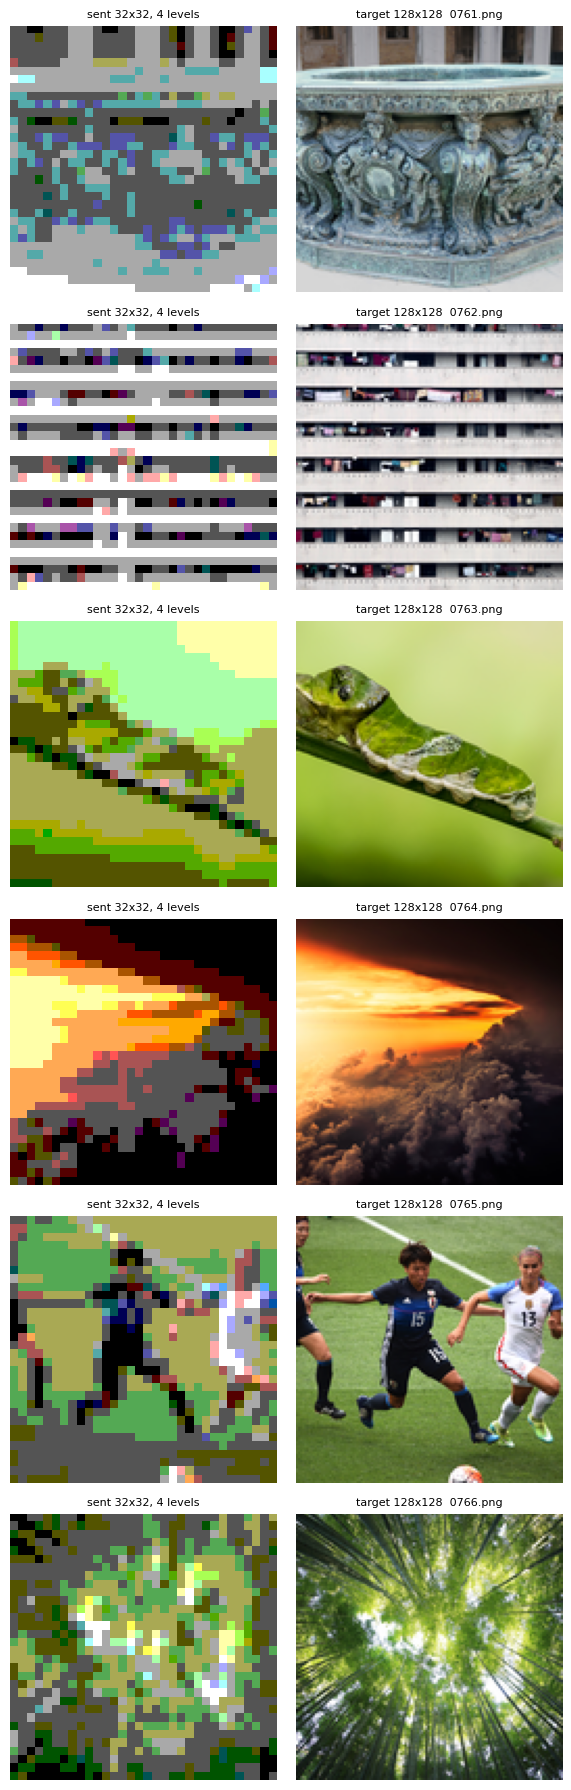

In [39]:
# ===== Cell 9 — look at the Track 2 pairs =====
import matplotlib.pyplot as plt

d = np.load(OUT2 / "test.npz")
meta = json.load(open(OUT2 / "test.json"))
x, y = d["x"].astype(np.float32), d["y"].astype(np.float32)

fig, axes = plt.subplots(6, 2, figsize=(6, 18))
for row, i in zip(axes, range(0, 24, 4)):          # every 4th = one flip per image
    row[0].imshow(np.clip(x[i], 0, 1), interpolation="nearest")
    row[0].set_title(f"sent {SMALL}x{SMALL}, {LEVELS} levels", fontsize=8)
    row[1].imshow(np.clip(y[i], 0, 1))
    row[1].set_title(f"target {BIG}x{BIG}  {meta[i]['source']}", fontsize=8)
    row[0].axis("off"); row[1].axis("off")
plt.tight_layout()

wrong = (np.abs(x[:50] - np.stack([quantize(np.asarray(Image.fromarray((yy * 255).astype(np.uint8))
          .resize((SMALL, SMALL), Image.LANCZOS), dtype=np.float32) / 255.0, LEVELS) for yy in y[:50]])[:50]) > 1e-3)
print(f"injected error rate in first 50: {wrong.mean():.5f}  (target {SYMBOL_ERROR_RATE})")

In [40]:
import math, time, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from pathlib import Path

assert torch.cuda.is_available(), "Turn on a GPU in Settings -> Accelerator"
dev = "cuda"
OUT2 = Path("/kaggle/working/pairs_upscale")

def load(name):
    d = np.load(OUT2 / f"{name}.npz")
    x = torch.from_numpy(d["x"].astype(np.float32)).permute(0, 3, 1, 2).contiguous()  # (N,3,32,32)
    y = torch.from_numpy(d["y"].astype(np.float32)).permute(0, 3, 1, 2).contiguous()  # (N,3,128,128)
    return x, y

xtr, ytr = load("train")
xte, yte = load("test")
print("train", xtr.shape, ytr.shape, "  test", xte.shape, yte.shape)


class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.body = nn.Sequential(nn.Conv2d(c, c, 3, padding=1), nn.GELU(),
                                  nn.Conv2d(c, c, 3, padding=1))
    def forward(self, x):
        return x + self.body(x)


class UpscaleUNet(nn.Module):
    """Bicubic-upsample the 32x32 input to 128x128, then a small U-Net predicts
    the correction. Output = bicubic + correction, so the network only learns
    what bicubic gets wrong. The last layer starts at zero, so an untrained
    model is exactly bicubic - training can only improve on it."""
    def __init__(self, c=32):
        super().__init__()
        self.inp = nn.Conv2d(3, c, 3, padding=1)
        self.e1 = nn.Sequential(ResBlock(c), ResBlock(c))                   # 128
        self.d1 = nn.Conv2d(c, 2 * c, 2, stride=2)
        self.e2 = nn.Sequential(ResBlock(2 * c), ResBlock(2 * c))           # 64
        self.d2 = nn.Conv2d(2 * c, 4 * c, 2, stride=2)
        self.e3 = nn.Sequential(ResBlock(4 * c), ResBlock(4 * c))           # 32
        self.d3 = nn.Conv2d(4 * c, 8 * c, 2, stride=2)
        self.mid = nn.Sequential(ResBlock(8 * c), ResBlock(8 * c))          # 16
        self.u3 = nn.ConvTranspose2d(8 * c, 4 * c, 2, stride=2); self.f3 = nn.Conv2d(8 * c, 4 * c, 1); self.r3 = ResBlock(4 * c)
        self.u2 = nn.ConvTranspose2d(4 * c, 2 * c, 2, stride=2); self.f2 = nn.Conv2d(4 * c, 2 * c, 1); self.r2 = ResBlock(2 * c)
        self.u1 = nn.ConvTranspose2d(2 * c, c, 2, stride=2);     self.f1 = nn.Conv2d(2 * c, c, 1);     self.r1 = ResBlock(c)
        self.out = nn.Conv2d(c, 3, 3, padding=1)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)

    def forward(self, small):
        up = F.interpolate(small, scale_factor=4, mode="bicubic", align_corners=False)
        h1 = self.e1(self.inp(up))
        h2 = self.e2(self.d1(h1))
        h3 = self.e3(self.d2(h2))
        m = self.mid(self.d3(h3))
        h = self.r3(self.f3(torch.cat([self.u3(m), h3], 1)))
        h = self.r2(self.f2(torch.cat([self.u2(h), h2], 1)))
        h = self.r1(self.f1(torch.cat([self.u1(h), h1], 1)))
        return up + self.out(h)


def psnr(a, b):
    mse = ((a - b) ** 2).mean(dim=(1, 2, 3)).clamp_min(1e-10)
    return (10 * torch.log10(1.0 / mse)).tolist()


@torch.no_grad()
def evaluate(model):
    """L1 and mean PSNR on the test set, for the model AND plain bicubic.
    Bicubic is the baseline - the model is only worth what it adds on top."""
    model.eval()
    l1_sum, p_model, p_bic = 0.0, [], []
    for i in range(0, len(xte), 32):
        xs, ys = xte[i:i + 32].to(dev), yte[i:i + 32].to(dev)
        pred = model(xs).clamp(0, 1)
        bic = F.interpolate(xs, size=(128, 128), mode="bicubic", align_corners=False).clamp(0, 1)
        l1_sum += F.l1_loss(pred, ys, reduction="sum").item()
        p_model += psnr(pred, ys)
        p_bic += psnr(bic, ys)
    model.train()
    return l1_sum / yte.numel(), float(np.mean(p_model)), float(np.mean(p_bic))


model = UpscaleUNet().to(dev)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters")
print("untrained (should equal bicubic): L1 %.4f  PSNR model %.2f  bicubic %.2f" % evaluate(model))

train torch.Size([3040, 3, 32, 32]) torch.Size([3040, 3, 128, 128])   test torch.Size([160, 3, 32, 32]) torch.Size([160, 3, 128, 128])
3.91M parameters
untrained (should equal bicubic): L1 0.0974  PSNR model 18.33  bicubic 18.33


In [41]:
EPOCHS, BS, LR, PATIENCE = 120, 16, 2e-4, 20
CKPT = "/kaggle/working/upscaler_best.pt"

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS * math.ceil(len(xtr) / BS))
scaler = torch.amp.GradScaler("cuda")

best, bad = float("inf"), 0
for ep in range(EPOCHS):
    t0, running = time.time(), 0.0
    perm = torch.randperm(len(xtr))
    for i in range(0, len(xtr), BS):
        idx = perm[i:i + BS]
        xs, ys = xtr[idx].to(dev, non_blocking=True), ytr[idx].to(dev, non_blocking=True)
        with torch.autocast("cuda", dtype=torch.float16):
            loss = F.l1_loss(model(xs), ys)       # L1, no GAN: keeps residual errors visible
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        sched.step()
        running += loss.item() * len(idx)

    val_l1, p_model, p_bic = evaluate(model)
    print(f"ep {ep + 1:3d}  train L1 {running / len(xtr):.4f}  test L1 {val_l1:.4f}  "
          f"PSNR model {p_model:.2f} dB  bicubic {p_bic:.2f} dB  ({time.time() - t0:.0f}s)")

    if val_l1 < best:
        best, bad = val_l1, 0
        torch.save(model.state_dict(), CKPT)
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f"early stop - no improvement for {PATIENCE} epochs")
            break

print("best test L1", best, "-> saved", CKPT)

ep   1  train L1 0.0909  test L1 0.0866  PSNR model 19.20 dB  bicubic 18.33 dB  (12s)
ep   2  train L1 0.0849  test L1 0.0829  PSNR model 19.48 dB  bicubic 18.33 dB  (11s)
ep   3  train L1 0.0830  test L1 0.0819  PSNR model 19.53 dB  bicubic 18.33 dB  (11s)
ep   4  train L1 0.0820  test L1 0.0808  PSNR model 19.60 dB  bicubic 18.33 dB  (11s)
ep   5  train L1 0.0813  test L1 0.0795  PSNR model 19.71 dB  bicubic 18.33 dB  (12s)
ep   6  train L1 0.0803  test L1 0.0788  PSNR model 19.78 dB  bicubic 18.33 dB  (12s)
ep   7  train L1 0.0796  test L1 0.0780  PSNR model 19.82 dB  bicubic 18.33 dB  (12s)
ep   8  train L1 0.0786  test L1 0.0776  PSNR model 19.86 dB  bicubic 18.33 dB  (12s)
ep   9  train L1 0.0779  test L1 0.0767  PSNR model 19.94 dB  bicubic 18.33 dB  (12s)
ep  10  train L1 0.0770  test L1 0.0767  PSNR model 19.93 dB  bicubic 18.33 dB  (12s)
ep  11  train L1 0.0761  test L1 0.0762  PSNR model 19.95 dB  bicubic 18.33 dB  (12s)
ep  12  train L1 0.0753  test L1 0.0761  PSNR model 19

test PSNR   bicubic 18.33 dB   model 19.97 dB   gain +1.64 dB


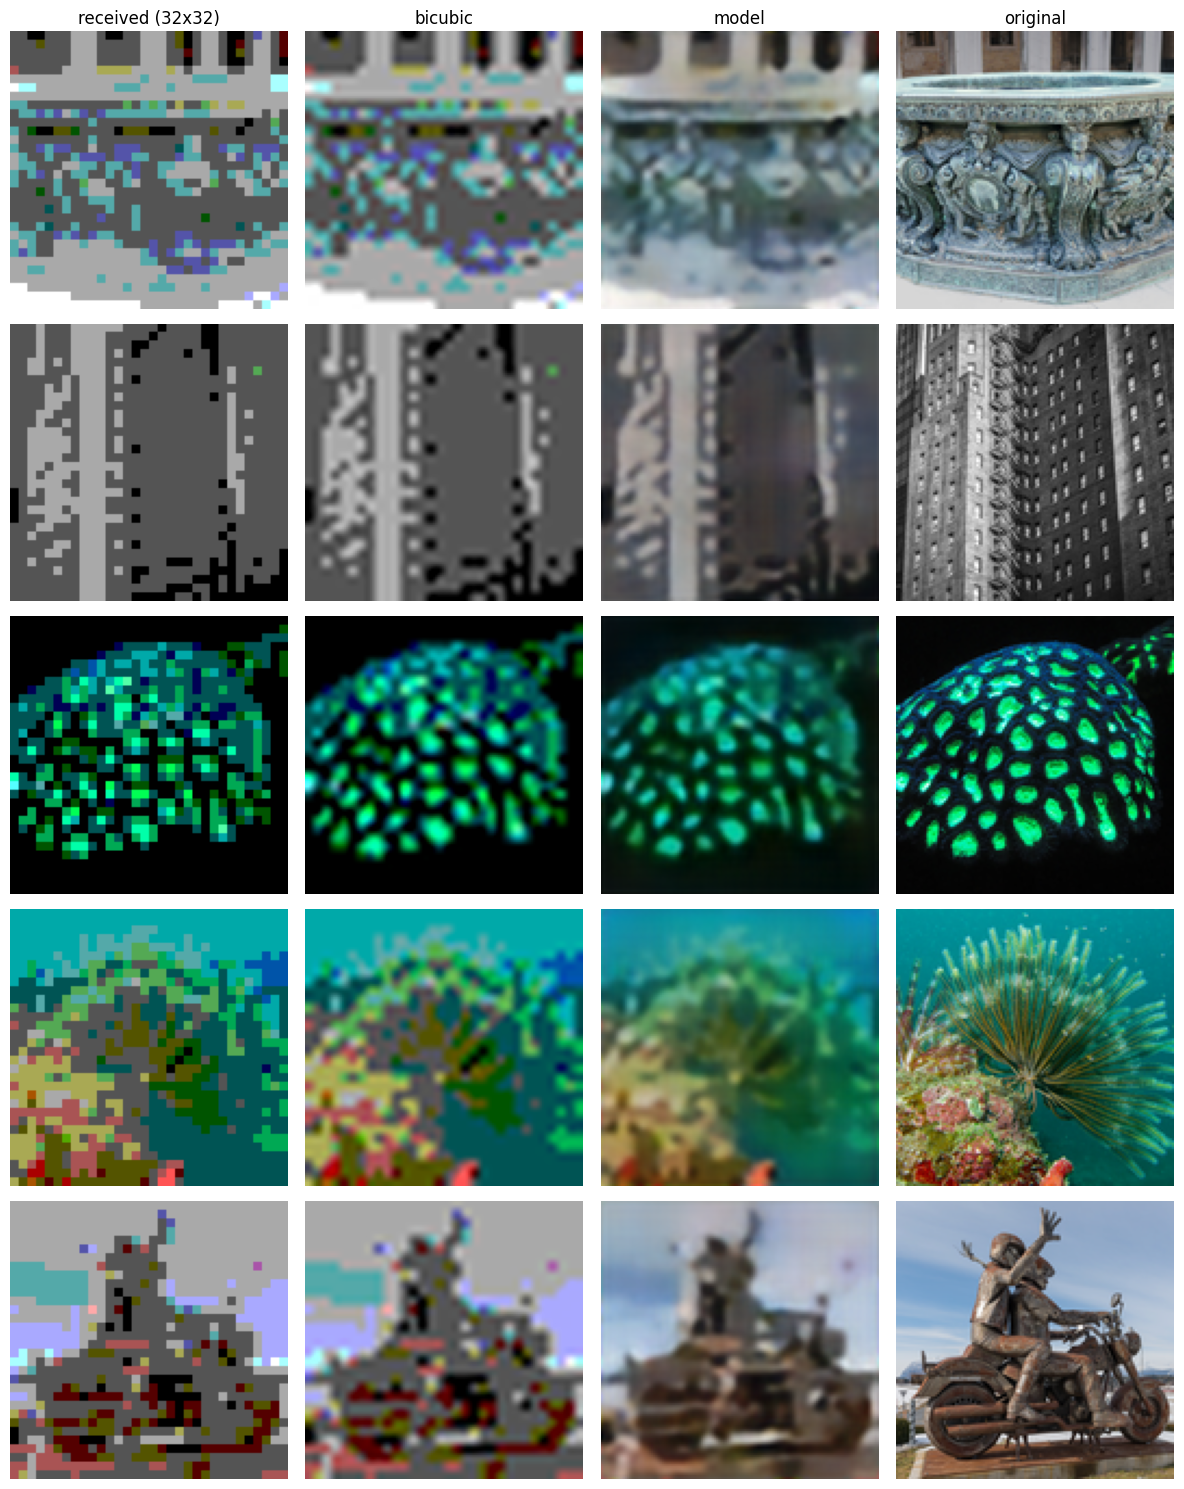

In [42]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(CKPT))
model.eval()

idx = [0, 32, 64, 96, 128]          # multiples of 4 = unflipped originals
with torch.no_grad():
    xs = xte[idx].to(dev)
    views = {
        "received (32x32)": F.interpolate(xs, size=(128, 128), mode="nearest"),
        "bicubic":          F.interpolate(xs, size=(128, 128), mode="bicubic", align_corners=False),
        "model":            model(xs),
        "original":         yte[idx].to(dev),
    }
    views = {k: v.clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy() for k, v in views.items()}

fig, axes = plt.subplots(len(idx), 4, figsize=(12, 3 * len(idx)))
for r in range(len(idx)):
    for c, (name, arr) in enumerate(views.items()):
        axes[r, c].imshow(arr[r])
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(name)
plt.tight_layout()

_, p_model, p_bic = evaluate(model)
print(f"test PSNR   bicubic {p_bic:.2f} dB   model {p_model:.2f} dB   gain {p_model - p_bic:+.2f} dB")

In [43]:
from IPython.display import FileLink
import os

for f in ["upscaler_best.pt", "upscaler_v1.pt"]:
    p = f"/kaggle/working/{f}"
    if os.path.exists(p):
        print(f, f"{os.path.getsize(p)/1e6:.1f} MB")
        display(FileLink(p))

upscaler_best.pt 15.7 MB


/kaggle/working/upscaler_best.pt

## Now for track 1


In [44]:
import numpy as np, spectral.encoder.audio_encoder as AE

_orig = AE.encode_activation_matrix

def fast_encode_activation_matrix(frame_samples, row_frequencies, activation_to_encode, t):
    table = np.sin(2 * np.pi * np.outer(np.asarray(row_frequencies), t))   # (rows, frame_samples)
    frames = (np.asarray(activation_to_encode, dtype=np.float64).T @ table) * np.hanning(frame_samples)
    return frames.ravel()

# verify identical before swapping in
rng = np.random.default_rng(0)
act = rng.random((32, 8)); freqs = np.linspace(8000, 1000, 32); t = np.arange(4410) / 44100
a, b = _orig(4410, freqs, act, t), fast_encode_activation_matrix(4410, freqs, act, t)
print("max difference:", np.abs(a - b).max())     # expect ~1e-13
assert np.allclose(a, b)

AE.encode_activation_matrix = fast_encode_activation_matrix
print("encoder vectorised")

max difference: 0.0
encoder vectorised


In [47]:
import numpy as np

DEAD = 0.05          # below this, a row is destroyed rather than attenuated
TARGET_PEAK = 0.8    # matches the encoder's unsecured normalisation

def calibration_frame(metadata):
    """One frame with every row at equal amplitude. Random phases keep its peak
    near the image audio's, so it is not clipped harder than the signal.
    Returns (samples, expected_per_row_magnitude)."""
    fs, N = metadata["sample_rate"], metadata["frame_samples"]
    f = np.asarray(metadata["row_frequencies"])
    t = np.arange(N) / fs
    phases = np.random.default_rng(12345).uniform(0, 2 * np.pi, len(f))
    raw = np.sin(2 * np.pi * np.outer(f, t) + phases[:, None]).sum(0) * np.hanning(N)
    s = TARGET_PEAK / np.abs(raw).max()
    return raw * s, s * np.hanning(N).sum() / 2.0


def estimate_H(cal_received, metadata, expected):
    """|H(f_r)| straight off the received calibration frame.

    Each row is one frequency, so an LTI channel can only SCALE it:
        |X_cal[k_r]| = A_cal * |H(f_r)| * sum(hann)/2
    Blind - needs no knowledge of what the channel did."""
    N, fs = metadata["frame_samples"], metadata["sample_rate"]
    bins = np.round(np.asarray(metadata["row_frequencies"]) / (fs / N)).astype(int)
    return np.abs(np.fft.rfft(cal_received))[bins] / expected

In [48]:
import json, hashlib
from multiprocessing import Pool
from pathlib import Path
from PIL import Image
from spectral.encoder.audio_encoder import encode
from spectral.decoder.stft_decoder import decode
from spectral.decoder.image_reconstructor import recover_activation
from spectral.channel.effects import apply_chain

ROWS = COLS = 128
VARIANTS = 2
OUT1 = Path("/kaggle/working/pairs_track1"); OUT1.mkdir(exist_ok=True)
TRANSFORMS = [None, Image.Transpose.FLIP_LEFT_RIGHT,
              Image.Transpose.FLIP_TOP_BOTTOM, Image.Transpose.ROTATE_180]

ROW_INDEX = np.linspace(0, 1, ROWS, dtype=np.float32)[:, None] * np.ones((1, COLS), np.float32)


def sample_chain(rng):
    if rng.random() < 0.15:
        return []
    kind = rng.choice(["clip", "lowpass", "bandstop", "echo", "resample"],
                      p=[0.35, 0.18, 0.17, 0.15, 0.15])
    c = {"clip":     lambda: {"type": "clip", "threshold": float(rng.uniform(0.15, 0.5))},
         "lowpass":  lambda: {"type": "lowpass", "cutoff": float(rng.uniform(2500, 7000))},
         "bandstop": lambda: (lambda lo: {"type": "bandstop", "low": lo,
                                          "high": lo + float(rng.uniform(300, 1200))})(float(rng.uniform(1500, 6000))),
         "echo":     lambda: {"type": "echo", "delay": float(rng.uniform(0.02, 0.15)),
                              "decay": float(rng.uniform(0.2, 0.6))},
         "resample": lambda: {"type": "resample", "target_rate": int(rng.choice([8000, 11025, 16000, 22050])),
                              "anti_alias": bool(rng.random() < 0.5)}}[kind]()
    chain = [c]
    if rng.random() < 0.7:
        chain.append({"type": "noise", "snr_db": float(rng.uniform(10, 40))})
    return chain


def one_sample(audio, metadata, cal, expected, chain):
    """-> (5,128,128) model input: 3x inverted RGB + row index + |H| confidence."""
    out = apply_chain(np.concatenate([cal, audio]), metadata["sample_rate"], chain)
    N = metadata["frame_samples"]
    per = metadata["columns"] * N
    need = N + 3 * per
    if len(out) < need:
        out = np.concatenate([out, np.zeros(need - len(out))])

    H = estimate_H(out[:N], metadata, expected)
    safe = np.maximum(H, DEAD)          # never divide by a destroyed row

    acts = []
    for i in range(3):
        mag = decode(out[N + i * per: N + (i + 1) * per], metadata)
        acts.append(recover_activation(mag / safe[:, None], metadata))

    conf = np.clip(H, 0, 1).astype(np.float32)[:, None] * np.ones((1, COLS), np.float32)
    return np.stack(acts + [ROW_INDEX, conf]).astype(np.float16)     # (5,H,W)


def process_one(path_str):
    path = Path(path_str)
    try:
        rng = np.random.default_rng(int(hashlib.sha256(path.name.encode()).hexdigest()[:16], 16))
        src = Image.open(path).convert("RGB")
        res = []
        for ti, tf in enumerate(TRANSFORMS):
            img = src if tf is None else src.transpose(tf)
            audio, meta, clean = encode(img, target_width=COLS, target_height=ROWS,
                                        mode="RGB", security_enabled=False)
            cal, expected = calibration_frame(meta)
            y = np.asarray(clean, dtype=np.float32).transpose(2, 0, 1).astype(np.float16)
            for v in range(VARIANTS):
                ch = sample_chain(rng)
                res.append((one_sample(audio, meta, cal, expected, ch), y,
                            {"source": path.name, "transform": ti,
                             "kind": ch[0]["type"] if ch else "clean"}))
        return res, None
    except Exception as exc:
        return [], f"{path.name}: {type(exc).__name__}: {exc}"


def build1(paths, name):
    xs, ys, meta, errs = [], [], [], []
    with Pool(os.cpu_count()) as pool:
        for i, (res, err) in enumerate(pool.imap(process_one, paths, chunksize=2)):
            if err:
                errs.append(err); print("  skip", err)
            for x, y, m in res:
                xs.append(x); ys.append(y); meta.append(m)
            if (i + 1) % 50 == 0:
                print(f"  {name}: {i + 1}/{len(paths)} images, {len(xs)} pairs", flush=True)
    np.savez_compressed(OUT1 / f"{name}.npz", x=np.stack(xs), y=np.stack(ys))
    (OUT1 / f"{name}.json").write_text(json.dumps(meta))
    print(f"{name}: {len(xs)} pairs, {len(errs)} skipped")


build1(test_paths[:4], "smoke")        # check this first

smoke: 32 pairs, 0 skipped


In [51]:
build1(train_paths, "train")
build1(test_paths,  "test")

KeyboardInterrupt: 

In [50]:
def load1(name):
    d = np.load(OUT1 / f"{name}.npz")
    return (torch.from_numpy(d["x"].astype(np.float32)),
            torch.from_numpy(d["y"].astype(np.float32)),
            json.load(open(OUT1 / f"{name}.json")))

xtr1, ytr1, _ = load1("train")
xte1, yte1, mte1 = load1("test")
print(xtr1.shape, ytr1.shape)


class RestoreUNet(UpscaleUNet):
    """Same body as the upscaler: 5 channels in, no resize, predicts the
    correction to the analytic stage's output."""
    def __init__(self, c=32):
        super().__init__(c)
        self.inp = nn.Conv2d(5, c, 3, padding=1)

    def forward(self, x):
        h1 = self.e1(self.inp(x))
        h2 = self.e2(self.d1(h1))
        h3 = self.e3(self.d2(h2))
        m = self.mid(self.d3(h3))
        h = self.r3(self.f3(torch.cat([self.u3(m), h3], 1)))
        h = self.r2(self.f2(torch.cat([self.u2(h), h2], 1)))
        h = self.r1(self.f1(torch.cat([self.u1(h), h1], 1)))
        return x[:, :3] + self.out(h)


@torch.no_grad()
def evaluate1(model):
    """PSNR per degradation type: analytic stage alone vs analytic + model."""
    model.eval()
    rows = {}
    for i in range(0, len(xte1), 16):
        xs, ys = xte1[i:i + 16].to(dev), yte1[i:i + 16].to(dev)
        pm = psnr(model(xs).clamp(0, 1), ys)
        pa = psnr(xs[:, :3].clamp(0, 1), ys)
        for j, (a, m) in enumerate(zip(pa, pm)):
            rows.setdefault(mte1[i + j]["kind"], []).append((a, m))
    model.train()
    return {k: (float(np.mean([a for a, _ in v])), float(np.mean([m for _, m in v])), len(v))
            for k, v in rows.items()}


model1 = RestoreUNet().to(dev)
opt = torch.optim.AdamW(model1.parameters(), lr=2e-4, weight_decay=1e-4)
EPOCHS1, BS1 = 80, 16
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS1 * math.ceil(len(xtr1) / BS1))
scaler = torch.amp.GradScaler("cuda")
CKPT1, best, bad = "/kaggle/working/restore_best.pt", float("inf"), 0

for ep in range(EPOCHS1):
    perm = torch.randperm(len(xtr1)); run = 0.0
    for i in range(0, len(xtr1), BS1):
        idx = perm[i:i + BS1]
        xs, ys = xtr1[idx].to(dev), ytr1[idx].to(dev)
        with torch.autocast("cuda", dtype=torch.float16):
            loss = F.l1_loss(model1(xs), ys)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        run += loss.item() * len(idx)

    with torch.no_grad():
        val = F.l1_loss(model1(xte1[:64].to(dev)), yte1[:64].to(dev)).item()
    print(f"ep {ep+1:3d}  train {run/len(xtr1):.4f}  test {val:.4f}")
    if val < best:
        best, bad = val, 0; torch.save(model1.state_dict(), CKPT1)
    else:
        bad += 1
        if bad >= 12:
            print("early stop"); break

model1.load_state_dict(torch.load(CKPT1))
print(f"\n{'degradation':<12} {'analytic':>9} {'+model':>9} {'gain':>7}  n")
for k, (a, m, n) in sorted(evaluate1(model1).items()):
    print(f"{k:<12} {a:9.2f} {m:9.2f} {m-a:+7.2f}  {n}")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/pairs_track1/train.npz'